# Campaign Sensor Ranking Example

This notebook demonstrates how to run the dynamic sensor-ranking workflow for one stored campaign under `data/campaigns/<campaign_label>/`.

**System boundary**
- Domain/core: `measurement_calibration.sensor_ranking` owns CSV parsing, campaign row alignment, PSD-distribution diagnostics, and record-wise ranking.
- Application/orchestration: this notebook chooses `campaign_label`, executes the analyzer, and renders summary tables and plots.
- Side effects: local filesystem reads under `data/campaigns/` and notebook plots only.
- Pattern choice: the notebook stays thin so ranking behavior remains testable outside Jupyter.


In [13]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import measurement_calibration.sensor_ranking as sensor_ranking_module  # noqa: E402

sensor_ranking_module = importlib.reload(sensor_ranking_module)
DEFAULT_CAMPAIGNS_DATA_DIR = sensor_ranking_module.DEFAULT_CAMPAIGNS_DATA_DIR
FileSystemCampaignSensorDataRepository = (
    sensor_ranking_module.FileSystemCampaignSensorDataRepository
)
SensorRankingAnalysisConfig = sensor_ranking_module.SensorRankingAnalysisConfig
analyze_campaign_sensor_ranking = (
    sensor_ranking_module.analyze_campaign_sensor_ranking
)
build_campaign_alignment_rows = sensor_ranking_module.build_campaign_alignment_rows
build_distribution_summary_rows = (
    sensor_ranking_module.build_distribution_summary_rows
)
build_score_stability_rows = sensor_ranking_module.build_score_stability_rows
build_sensor_integrity_rows = sensor_ranking_module.build_sensor_integrity_rows
build_sensor_ranking_rows = sensor_ranking_module.build_sensor_ranking_rows


## Configure The Campaign

Choose any campaign label already stored under `data/campaigns/`. The example defaults to `test-calibration` because it is a repository fixture, but the caller can replace it with any other available label.


In [14]:
campaigns_root = REPO_ROOT / DEFAULT_CAMPAIGNS_DATA_DIR
repository = FileSystemCampaignSensorDataRepository(campaigns_root=campaigns_root)
available_campaign_labels = repository.list_campaign_labels()

campaign_label = "MeasurementCalibration"
analysis_config = SensorRankingAnalysisConfig(
    ranking_histogram_bins=50,
    distribution_histogram_bins=150,
)

if campaign_label not in available_campaign_labels:
    raise ValueError(
        f"Unknown campaign_label={campaign_label!r}. "
        f"Available labels: {available_campaign_labels}"
    )

display(
    pd.DataFrame(
        [
            {
                "campaign_label": campaign_label,
                "campaigns_root": str(campaigns_root.relative_to(REPO_ROOT)),
                "available_campaign_labels": ", ".join(available_campaign_labels),
                "ranking_histogram_bins": analysis_config.ranking_histogram_bins,
                "distribution_histogram_bins": analysis_config.distribution_histogram_bins,
            }
        ]
    )
)


,campaign_label,campaigns_root,available_campaign_labels,ranking_histogram_bins,distribution_histogram_bins
0,MeasurementCalibration,data/campaigns,"MeasurementCalibration, test-calibration",50,150


## Run The Ranking Analysis

The analyzer loads every sensor CSV in the campaign directory, aligns rows by timestamp when needed, and then computes both the record-wise ranking and the dataset-wide distribution diagnostic.


In [15]:
analysis = analyze_campaign_sensor_ranking(
    campaign_label=campaign_label,
    campaigns_root=campaigns_root,
    config=analysis_config,
)

ranking_winner = analysis.ranking_result.ranking_sensor_ids[0]
distribution_winner = analysis.distribution_diagnostics.ranking_sensor_ids[0]

overview_frame = pd.DataFrame(
    [
        {
            "campaign_label": analysis.campaign_label,
            "n_sensors": analysis.dataset.n_sensors,
            "aligned_records": analysis.dataset.n_records,
            "n_frequencies": analysis.dataset.n_frequencies,
            "alignment_tolerance_ms": analysis.alignment_diagnostics.alignment_tolerance_ms,
            "ranking_winner_sensor_id": ranking_winner,
            "distribution_winner_sensor_id": distribution_winner,
        }
    ]
)
display(overview_frame)

if ranking_winner != distribution_winner:
    print(
        "The record-wise winner differs from the distribution winner. "
        "That usually means one sensor matches campaign-wide PSD values "
        "well, while another matches record-by-record spectral shape better."
    )


,campaign_label,n_sensors,aligned_records,n_frequencies,alignment_tolerance_ms,ranking_winner_sensor_id,distribution_winner_sensor_id
0,MeasurementCalibration,5,30,4096,5000,Node2,Node3


The record-wise winner differs from the distribution winner. That usually means one sensor matches campaign-wide PSD values well, while another matches record-by-record spectral shape better.


## Alignment Diagnostics And Sensor Integrity

The alignment table shows how many rows were retained after timestamp matching. The integrity table summarizes each aligned sensor on the exact dataset that was ranked.


In [16]:
alignment_frame = pd.DataFrame(
    build_campaign_alignment_rows(analysis.alignment_diagnostics)
).sort_values("sensor_id")
integrity_frame = pd.DataFrame(
    build_sensor_integrity_rows(analysis.dataset)
).sort_values("sensor_id")

display(alignment_frame)
display(integrity_frame)


,campaign_label,sensor_id,is_anchor_sensor,source_records,aligned_records,dropped_records,retained_fraction,alignment_tolerance_ms,mean_record_time_spread_ms,max_record_time_spread_ms
0,MeasurementCalibration,Node1,True,30,30,0,1.0,5000,1677.366667,2436.0
1,MeasurementCalibration,Node2,False,30,30,0,1.0,5000,1677.366667,2436.0
2,MeasurementCalibration,Node3,False,30,30,0,1.0,5000,1677.366667,2436.0
3,MeasurementCalibration,Node5,False,30,30,0,1.0,5000,1677.366667,2436.0
4,MeasurementCalibration,Node9,False,30,30,0,1.0,5000,1677.366667,2436.0


,sensor_id,records,timestamp_start_ms,timestamp_end_ms,acquisition_span_s,mean_psd_db,std_psd_db,min_psd_db,max_psd_db
0,Node1,30,1773181568011,1773185048045,3480.034,-20.926043,5.052557,-26.704881,8.593730
1,Node2,30,1773181568373,1773185048526,3480.153,-20.486492,4.648772,-25.469255,11.026123
2,Node3,30,1773181568837,1773185047890,3479.053,-20.314409,4.633043,-25.526529,8.048917
3,Node5,30,1773181569836,1773185049064,3479.228,-20.252926,4.398075,-24.775458,8.634416
4,Node9,30,1773181569572,1773185049953,3480.381,-19.658999,4.392322,-23.833609,6.458697


## Ranking Tables

Three complementary views are shown below:
- `ranking_frame`: the main record-wise cumulative-correlation ranking.
- `distribution_frame`: campaign-wide PSD-distribution similarity.
- `stability_frame`: how stable the record-wise ranking is across aligned records.


In [17]:
ranking_frame = pd.DataFrame(
    build_sensor_ranking_rows(analysis.ranking_result)
).sort_values("rank")
distribution_frame = pd.DataFrame(
    build_distribution_summary_rows(analysis.distribution_diagnostics)
).sort_values("rank")
stability_frame = pd.DataFrame(
    build_score_stability_rows(analysis.ranking_result)
).sort_values("rank")

display(ranking_frame)
display(distribution_frame)
display(stability_frame)


,rank,sensor_id,mean_score,mean_correlation,score_std,mean_noise_floor_db,records
0,1,Node2,3.478944,0.869736,0.012826,-24.596470,30
1,2,Node1,3.475203,0.868801,0.016346,-25.927254,30
2,3,Node3,3.308619,0.827155,0.022005,-24.468297,30
3,4,Node5,3.300382,0.825096,0.021525,-23.859449,30
4,5,Node9,3.020795,0.755199,0.026829,-23.108467,30


,rank,sensor_id,distribution_similarity,normalized_similarity,mean_psd_db,std_psd_db,min_psd_db,max_psd_db,value_count,is_low_similarity_outlier
0,1,Node3,3.057571,0.764393,-20.314409,4.633043,-25.526529,8.048917,122880,False
1,2,Node2,2.984223,0.746056,-20.486492,4.648772,-25.469255,11.026123,122880,False
2,3,Node5,2.890265,0.722566,-20.252926,4.398075,-24.775458,8.634416,122880,False
3,4,Node9,2.354437,0.588609,-19.658999,4.392322,-23.833609,6.458697,122880,True
4,5,Node1,2.301184,0.575296,-20.926043,5.052557,-26.704881,8.593730,122880,True


,rank,sensor_id,mean_score,mean_correlation,score_std,score_min,score_max,mean_rank,best_rank,worst_rank,top_1_count,top_1_fraction
0,1,Node2,3.478944,0.869736,0.012826,3.454923,3.501125,1.333333,1,2,20,0.666667
1,2,Node1,3.475203,0.868801,0.016346,3.441223,3.509931,1.666667,1,2,10,0.333333
2,3,Node3,3.308619,0.827155,0.022005,3.262049,3.350257,3.366667,3,4,0,0.000000
3,4,Node5,3.300382,0.825096,0.021525,3.245995,3.359800,3.633333,3,4,0,0.000000
4,5,Node9,3.020795,0.755199,0.026829,2.922715,3.060030,5.000000,5,5,0,0.000000


## Sensor Correlation Matrix

The ranking stores a full sensor-to-sensor Pearson correlation matrix for every aligned realization. The heatmap below averages those matrices across realizations so you can see the stable agreement structure of the campaign.


,Node1,Node2,Node3,Node5,Node9
Node1,1.000000,0.921693,0.902702,0.898447,0.752361
Node2,0.921693,1.000000,0.897761,0.870971,0.788519
Node3,0.902702,0.897761,1.000000,0.779602,0.728554
Node5,0.898447,0.870971,0.779602,1.000000,0.751362
Node9,0.752361,0.788519,0.728554,0.751362,1.000000


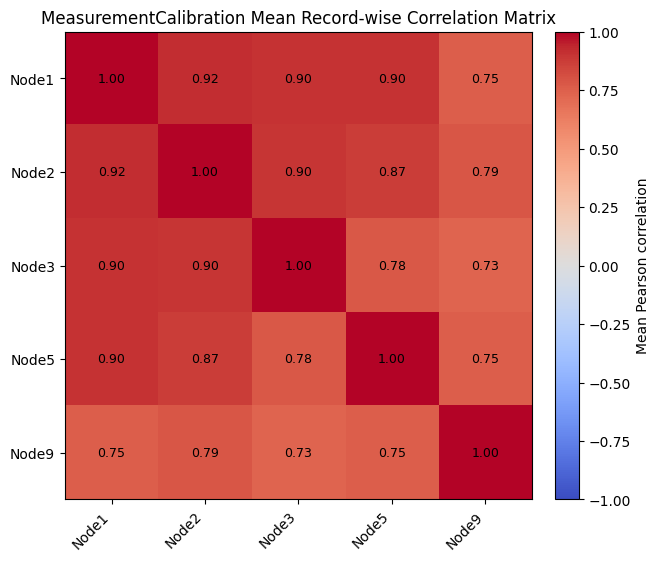

In [18]:
mean_recordwise_correlation = np.mean(
    analysis.ranking_result.per_record_correlation,
    axis=0,
)
mean_recordwise_correlation_frame = pd.DataFrame(
    mean_recordwise_correlation,
    index=analysis.dataset.sensor_ids,
    columns=analysis.dataset.sensor_ids,
)
display(mean_recordwise_correlation_frame)

fig, ax = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
image = ax.imshow(
    mean_recordwise_correlation,
    vmin=-1.0,
    vmax=1.0,
    cmap="coolwarm",
    aspect="auto",
)
ax.set_title(f"{campaign_label} Mean Record-wise Correlation Matrix")
ax.set_xticks(np.arange(analysis.dataset.n_sensors))
ax.set_xticklabels(analysis.dataset.sensor_ids, rotation=45, ha="right")
ax.set_yticks(np.arange(analysis.dataset.n_sensors))
ax.set_yticklabels(analysis.dataset.sensor_ids)

for row_index in range(analysis.dataset.n_sensors):
    for column_index in range(analysis.dataset.n_sensors):
        ax.text(
            column_index,
            row_index,
            f"{mean_recordwise_correlation[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Mean Pearson correlation")
plt.show()


## Correlation And Rank Evolution Across Realizations

The next plots show how each sensor behaves across aligned realizations:
- mean pairwise correlation to the rest of the network,
- rank position on each realization, and
- estimated histogram-mode noise floor used by the ranking recentering step.


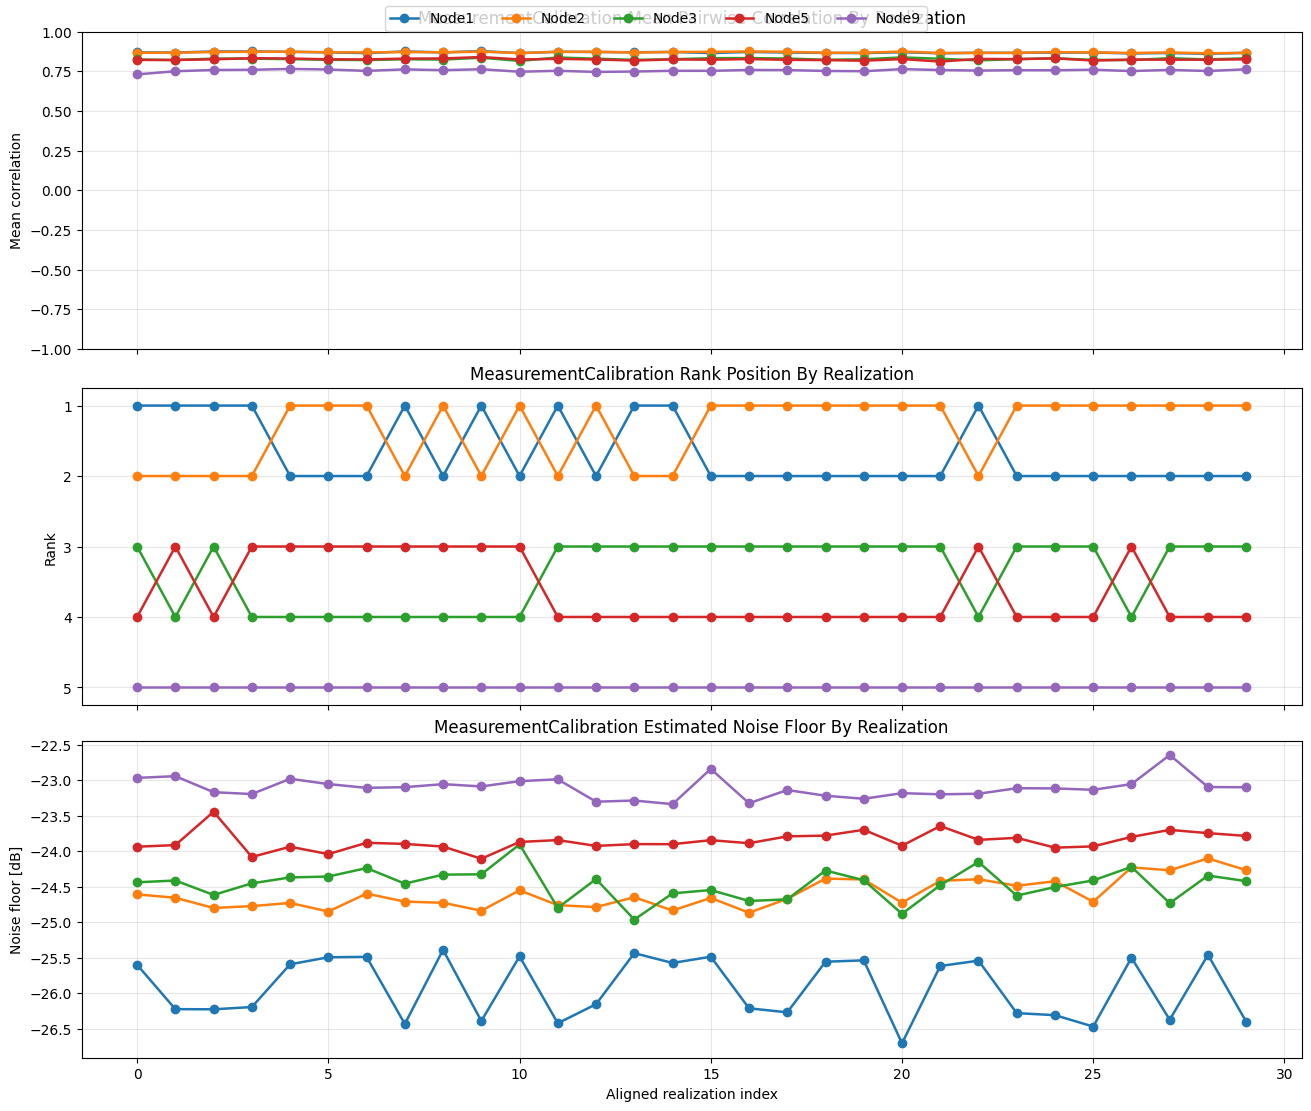

In [19]:
n_other_sensors = max(analysis.dataset.n_sensors - 1, 1)
per_record_mean_correlation = analysis.ranking_result.per_record_score / float(
    n_other_sensors
)
per_record_order = np.argsort(analysis.ranking_result.per_record_score, axis=0)[::-1]
per_record_rank = np.empty_like(per_record_order)
for record_index in range(analysis.dataset.n_records):
    per_record_rank[per_record_order[:, record_index], record_index] = np.arange(
        1,
        analysis.dataset.n_sensors + 1,
        dtype=np.int64,
    )

record_indices = np.arange(analysis.dataset.n_records, dtype=np.int64)
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True, constrained_layout=True)

for sensor_index, sensor_id in enumerate(analysis.dataset.sensor_ids):
    axes[0].plot(
        record_indices,
        per_record_mean_correlation[sensor_index],
        marker="o",
        linewidth=1.8,
        label=sensor_id,
    )
    axes[1].plot(
        record_indices,
        per_record_rank[sensor_index],
        marker="o",
        linewidth=1.8,
        label=sensor_id,
    )
    axes[2].plot(
        record_indices,
        analysis.ranking_result.noise_floor_db[sensor_index],
        marker="o",
        linewidth=1.8,
        label=sensor_id,
    )

axes[0].set_title(f"{campaign_label} Mean Pairwise Correlation By Realization")
axes[0].set_ylabel("Mean correlation")
axes[0].set_ylim(-1.0, 1.0)
axes[0].grid(alpha=0.3)

axes[1].set_title(f"{campaign_label} Rank Position By Realization")
axes[1].set_ylabel("Rank")
axes[1].set_ylim(analysis.dataset.n_sensors + 0.25, 0.75)
axes[1].set_yticks(np.arange(1, analysis.dataset.n_sensors + 1))
axes[1].grid(alpha=0.3)

axes[2].set_title(f"{campaign_label} Estimated Noise Floor By Realization")
axes[2].set_xlabel("Aligned realization index")
axes[2].set_ylabel("Noise floor [dB]")
axes[2].grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(analysis.dataset.n_sensors, 5))
plt.show()


## Diagnostic Plot

The left panel shows the mean correlation score used by the ranking. The right panel overlays the mean PSD curves for the top-ranked sensors on the aligned campaign records.


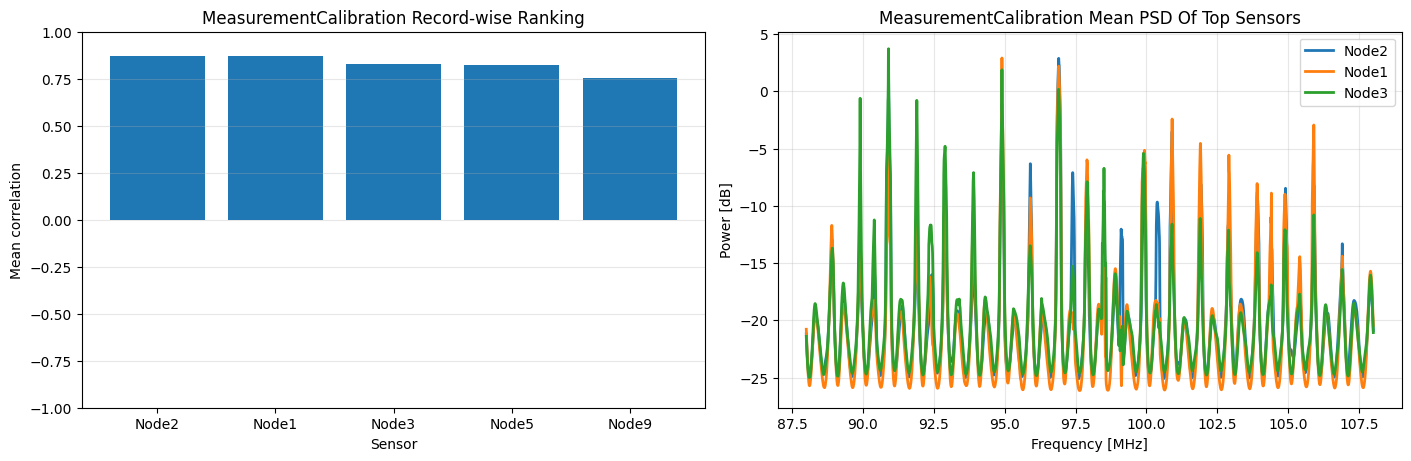

In [20]:
sensor_to_index = {
    sensor_id: sensor_index
    for sensor_index, sensor_id in enumerate(analysis.dataset.sensor_ids)
}
top_sensor_ids = list(
    analysis.ranking_result.ranking_sensor_ids[: min(3, analysis.dataset.n_sensors)]
)
frequency_mhz = analysis.dataset.frequency_hz / 1.0e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].bar(
    ranking_frame["sensor_id"],
    ranking_frame["mean_correlation"],
    color="tab:blue",
)
axes[0].set_title(f"{campaign_label} Record-wise Ranking")
axes[0].set_xlabel("Sensor")
axes[0].set_ylabel("Mean correlation")
axes[0].set_ylim(-1.0, 1.0)
axes[0].grid(axis="y", alpha=0.3)

for sensor_id in top_sensor_ids:
    sensor_index = sensor_to_index[sensor_id]
    mean_psd_db = np.mean(analysis.dataset.observations_db[sensor_index], axis=0)
    axes[1].plot(frequency_mhz, mean_psd_db, linewidth=2.0, label=sensor_id)

axes[1].set_title(f"{campaign_label} Mean PSD Of Top Sensors")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("Power [dB]")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.show()
